In [1]:
%matplotlib inline

In [9]:
import pandas as pd
from streamlit import columns
from sympy import true
df = pd.read_csv('C:/Users/pc/Desktop/CreditGuard/data/raw/loans_full_schema.csv')
data = df.drop(columns=[
    'Unnamed: 0','emp_title','state','sub_grade','issue_month',
    'initial_listing_status','disbursement_method','balance',
    'paid_total','paid_principal','paid_interest','paid_late_fees',
    'grade',
    'annual_income_joint','verification_income_joint','debt_to_income_joint',
    'months_since_last_delinq','months_since_90d_late','months_since_last_credit_inquiry'
])
data['loan_status'].value_counts()
default_categories = ['Late (16-30 days)', 'Late (31-120 days)', 'Charged Off']
data['default'] = data['loan_status'].isin(default_categories).astype(int)
data['loan_status'].unique()
data['default'].value_counts()
data = data.drop(columns=['loan_status'], axis=1)
data.columns
data.isnull().sum()



emp_length                      817
homeownership                     0
annual_income                     0
verified_income                   0
debt_to_income                   24
delinq_2y                         0
earliest_credit_line              0
inquiries_last_12m                0
total_credit_lines                0
open_credit_lines                 0
total_credit_limit                0
total_credit_utilized             0
num_collections_last_12m          0
num_historical_failed_to_pay      0
current_accounts_delinq           0
total_collection_amount_ever      0
current_installment_accounts      0
accounts_opened_24m               0
num_satisfactory_accounts         0
num_accounts_120d_past_due      318
num_accounts_30d_past_due         0
num_active_debit_accounts         0
total_debit_limit                 0
num_total_cc_accounts             0
num_open_cc_accounts              0
num_cc_carrying_balance           0
num_mort_accounts                 0
account_never_delinq_percent

C:\Users\pc\AppData\Local\Temp\ipykernel_15012\2307235693.py:21: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=data, x = data['num_accounts_120d_past_due'])


num_accounts_120d_past_due
0.0    9682
Name: count, dtype: int64

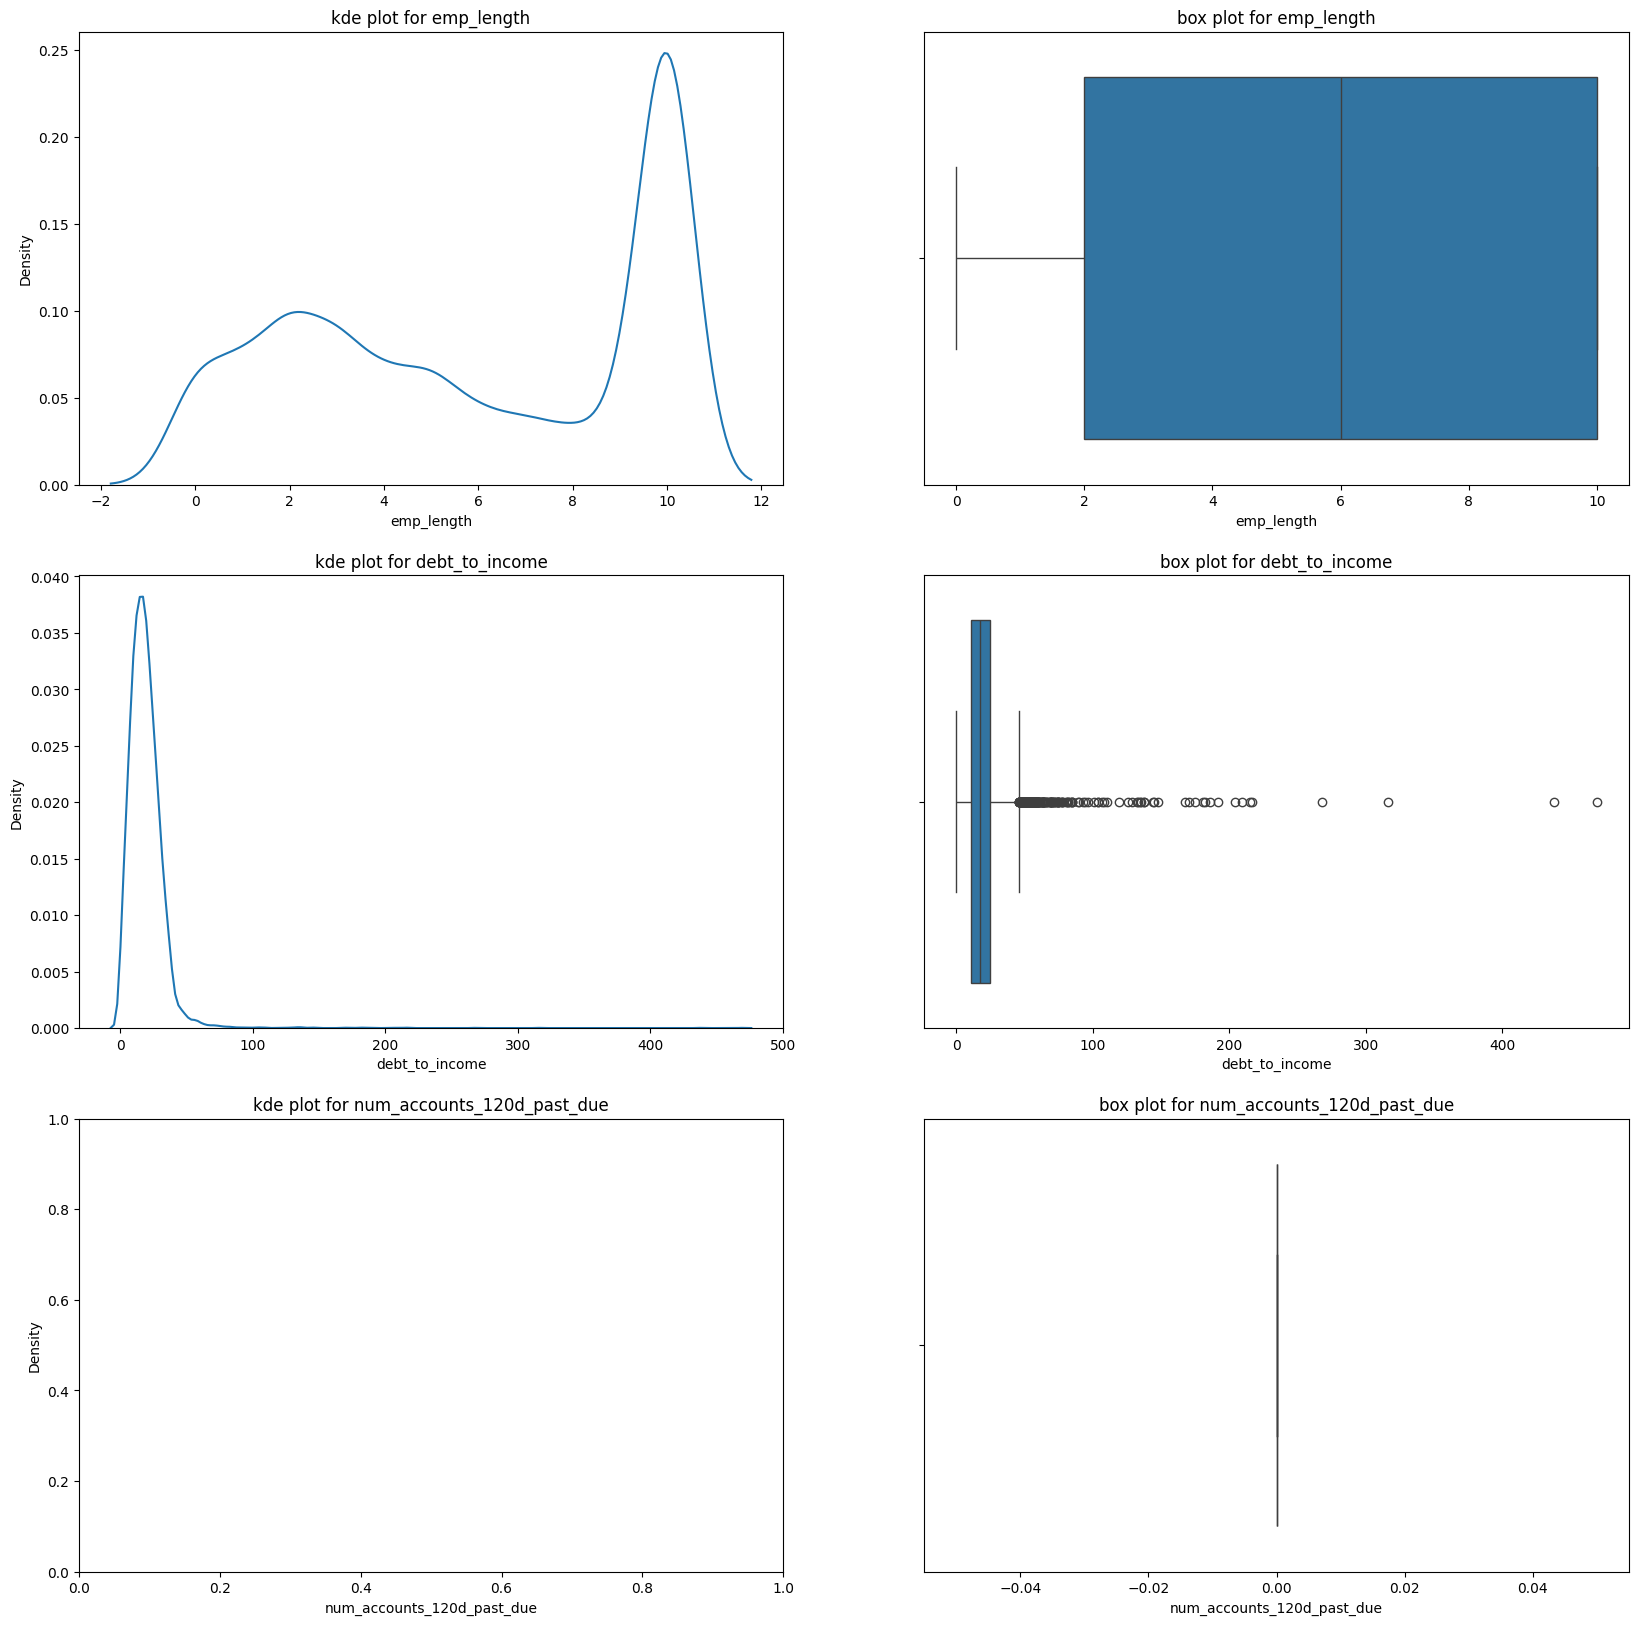

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(20,20))
plt.subplot(321)
sns.kdeplot(data=data, x = data['emp_length'])
plt.title("kde plot for emp_length")

plt.subplot(322)
sns.boxplot(data=data, x=data['emp_length'])
plt.title("box plot for emp_length")

plt.subplot(323)
sns.kdeplot(data=data, x = data['debt_to_income'])
plt.title("kde plot for debt_to_income")

plt.subplot(324)
sns.boxplot(data=data, x=data['debt_to_income'])
plt.title("box plot for debt_to_income")

plt.subplot(325)
sns.kdeplot(data=data, x = data['num_accounts_120d_past_due'])
plt.title("kde plot for num_accounts_120d_past_due")

plt.subplot(326)
sns.boxplot(data=data, x=data['num_accounts_120d_past_due'])
plt.title("box plot for num_accounts_120d_past_due")

data['num_accounts_120d_past_due'].value_counts()

In [10]:
data['num_accounts_120d_past_due'].value_counts()
data.shape

(10000, 37)

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 37 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   emp_length                    9183 non-null   float64
 1   homeownership                 10000 non-null  object 
 2   annual_income                 10000 non-null  float64
 3   verified_income               10000 non-null  object 
 4   debt_to_income                9976 non-null   float64
 5   delinq_2y                     10000 non-null  int64  
 6   earliest_credit_line          10000 non-null  int64  
 7   inquiries_last_12m            10000 non-null  int64  
 8   total_credit_lines            10000 non-null  int64  
 9   open_credit_lines             10000 non-null  int64  
 10  total_credit_limit            10000 non-null  int64  
 11  total_credit_utilized         10000 non-null  int64  
 12  num_collections_last_12m      10000 non-null  int64  
 13  nu

In [12]:
temp_data = data.select_dtypes(include='number')
temp_data = temp_data.drop(columns=['default'],axis=1)
temp_data.columns

Index(['emp_length', 'annual_income', 'debt_to_income', 'delinq_2y',
       'earliest_credit_line', 'inquiries_last_12m', 'total_credit_lines',
       'open_credit_lines', 'total_credit_limit', 'total_credit_utilized',
       'num_collections_last_12m', 'num_historical_failed_to_pay',
       'current_accounts_delinq', 'total_collection_amount_ever',
       'current_installment_accounts', 'accounts_opened_24m',
       'num_satisfactory_accounts', 'num_accounts_120d_past_due',
       'num_accounts_30d_past_due', 'num_active_debit_accounts',
       'total_debit_limit', 'num_total_cc_accounts', 'num_open_cc_accounts',
       'num_cc_carrying_balance', 'num_mort_accounts',
       'account_never_delinq_percent', 'tax_liens', 'public_record_bankrupt',
       'loan_amount', 'term', 'interest_rate', 'installment'],
      dtype='object')

In [13]:
cols_to_check = temp_data.columns
summary_list = []
for col in cols_to_check:
    entry = {
        'column' : col,
        'nunique' : temp_data[col].nunique(),
        'top_value' : temp_data[col].value_counts().index[0],
        'top_percentage' : temp_data[col].value_counts(normalize=True).values[0]*100
    }
    summary_list.append(entry)
summary_df = pd.DataFrame(summary_list)
summary_df
    

,column,nunique,top_value,top_percentage
0,emp_length,11,10.00,36.284439
1,annual_income,1463,60000.00,3.830000
2,debt_to_income,3673,0.00,0.280674
3,delinq_2y,12,0.00,85.760000
4,earliest_credit_line,53,2006.00,7.680000
5,inquiries_last_12m,26,0.00,30.600000
6,total_credit_lines,78,18.00,3.790000
7,open_credit_lines,45,9.00,8.370000
8,total_credit_limit,9119,21200.00,0.090000
9,total_credit_utilized,9497,0.00,0.280000


In [14]:
temp_data_cat = data.select_dtypes(include='object')
temp_data_cat

,homeownership,verified_income,loan_purpose,application_type
0,MORTGAGE,Verified,moving,individual
1,RENT,Not Verified,debt_consolidation,individual
2,RENT,Source Verified,other,individual
3,RENT,Not Verified,debt_consolidation,individual
4,RENT,Verified,credit_card,joint
...,...,...,...,...
9995,RENT,Source Verified,other,individual
9996,MORTGAGE,Verified,debt_consolidation,individual
9997,MORTGAGE,Verified,debt_consolidation,joint
9998,MORTGAGE,Source Verified,other,individual


In [ ]:
from matplotlib import figure
import matplotlib.pyplot as plt
import seaborn as sns
figure(figsize=())
for i in range(4):
    columns_cat = temp_data_cat.columns[i]
    plt.subplot(4,2,(i+1))
    sns.countplot(data=temp_data_cat, x=columns_cat)
    plt.title(f"count plot for {columns_cat}")
plt.tight_layout()
plt.show()

NameError: name 'figsiz' is not defined

In [15]:
import numpy as np
purposed_data = temp_data_cat['loan_purpose'].value_counts(normalize=True)*100

In [16]:
rare_categories = purposed_data[purposed_data < 5].index
data['loan_purpose_grouped'] = np.where(
    data['loan_purpose'].isin(rare_categories),
    'Other',
    data['loan_purpose']
)
data['loan_purpose_grouped'].value_counts(normalize=True)*100

loan_purpose_grouped
debt_consolidation    51.44
credit_card           22.49
Other                 10.13
other                  9.14
home_improvement       6.80
Name: proportion, dtype: float64

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
data = data.drop(columns=['loan_purpose','num_accounts_120d_past_due'])

In [19]:
X = data.drop(columns=['default'])
y = data['default']
X.shape

(10000, 35)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2, stratify=y)

In [21]:
data.shape

(10000, 36)

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,PowerTransformer
from sklearn import set_config
group_1_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('powertransform', PowerTransformer())
])
group_2_pipeline = PowerTransformer()
group_3_pipeline = OrdinalEncoder(categories=[['Verified', 'Source Verified', 'Not Verified']])
group_4_pipeline = OneHotEncoder(handle_unknown='ignore')

group1_columns = ['emp_length','debt_to_income']
group2_columns = data.drop(columns=['emp_length','debt_to_income','homeownership','verified_income','application_type','loan_purpose_grouped', 'default']).columns.tolist()
group3_columns = ['verified_income']
group4_columns = ['homeownership','application_type','loan_purpose_grouped']
preprocessor = ColumnTransformer(transformers=[
    ('group_1',group_1_pipeline,group1_columns),
    ('group_2',group_2_pipeline,group2_columns),
    ('group_3',group_3_pipeline,group3_columns),
    ('group_4',group_4_pipeline,group4_columns)
])
final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model',LogisticRegression(class_weight='balanced', max_iter=1000))
    # ('model',DecisionTreeClassifier(class_weight='balanced'))
    # ('model',RandomForestClassifier(class_weight='balanced'))
])

set_config(display="diagram")
final_pipeline.fit(X_train,y_train)
y_pred = final_pipeline.predict(X_test)



c:\Users\pc\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\core\_methods.py:176: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
c:\Users\pc\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\core\_methods.py:187: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)


In [23]:
final_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('group_1',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('powertransform',
                                                                   PowerTransformer())]),
                                                  ['emp_length',
                                                   'debt_to_income']),
                                                 ('group_2', PowerTransformer(),
                                                  ['annual_income', 'delinq_2y',
                                                   'earliest_credit_line',
                                                   'inquiries_last_12m',
                                                   'total_credit_lines',
                                                   'open_credit_line...
                                                   'public_record_bankrupt',
                                                   'loan_amount', 'term',
                                                   'interest_rate',
                                                   'installment']),
                                                 ('group_3',
                                                  OrdinalEncoder(categories=[['Verified',
                                                                              'Source '
                                                                              'Verified',
                                                                              'Not '
                                                                              'Verified']]),
                                                  ['verified_income']),
                                                 ('group_4',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['homeownership',
                                                   'application_type',
                                                   'loan_purpose_grouped'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [24]:
y_proba = final_pipeline.predict_proba(X_test)[:, 1]
pd.DataFrame(y_proba[:10])
print(y_proba[:10])

[0.28110459 0.23167998 0.54029806 0.08295787 0.089536   0.30904656
 0.5318365  0.03660076 0.42748467 0.43651265]


In [25]:
from sklearn.metrics import confusion_matrix, recall_score, f1_score, precision_score
print(f"confusion matrix is :{confusion_matrix(y_test,y_pred)}")
print(f"precision score is :{precision_score(y_test,y_pred)}")
print(f"Recall score is :{recall_score(y_test,y_pred)}")
print(f"f1 score is :{f1_score(y_test,y_pred)}")

confusion matrix is :[[1435  543]
 [   7   15]]
precision score is :0.026881720430107527
Recall score is :0.6818181818181818
f1 score is :0.05172413793103448


In [26]:
for threshold in [0.2, 0.3, 0.4, 0.5]:
    y_pred_custom = (y_proba > threshold).astype(int)
    print(f"--- Threshold: {threshold} ---")
    print(confusion_matrix(y_test, y_pred_custom))
    print(f"Precision: {precision_score(y_test, y_pred_custom)}")
    print(f"Recall: {recall_score(y_test, y_pred_custom)}")
    print(f"F1: {f1_score(y_test, y_pred_custom)}")
    print()

--- Threshold: 0.2 ---
[[ 647 1331]
 [   2   20]]
Precision: 0.014803849000740192
Recall: 0.9090909090909091
F1: 0.0291332847778587

--- Threshold: 0.3 ---
[[ 961 1017]
 [   4   18]]
Precision: 0.017391304347826087
Recall: 0.8181818181818182
F1: 0.03405865657521287

--- Threshold: 0.4 ---
[[1236  742]
 [   5   17]]
Precision: 0.022397891963109356
Recall: 0.7727272727272727
F1: 0.04353393085787453

--- Threshold: 0.5 ---
[[1435  543]
 [   7   15]]
Precision: 0.026881720430107527
Recall: 0.6818181818181818
F1: 0.05172413793103448



In [27]:
sample_applicant = pd.DataFrame([{
    'emp_length': 5.0,
    'homeownership': 'RENT',
    'annual_income': 60000.0,
    'verified_income': 'Verified',
    'debt_to_income': 18.0,
    'delinq_2y': 0,
    'earliest_credit_line': 2005,
    'inquiries_last_12m': 2,
    'total_credit_lines': 20,
    'open_credit_lines': 9,
    'total_credit_limit': 100000,
    'total_credit_utilized': 30000,
    'num_collections_last_12m': 0,
    'num_historical_failed_to_pay': 0,
    'current_accounts_delinq': 0,
    'total_collection_amount_ever': 0,
    'current_installment_accounts': 2,
    'accounts_opened_24m': 3,
    'num_satisfactory_accounts': 15,
    'num_accounts_30d_past_due': 0,
    'num_active_debit_accounts': 3,
    'total_debit_limit': 20000,
    'num_total_cc_accounts': 10,
    'num_open_cc_accounts': 6,
    'num_cc_carrying_balance': 4,
    'num_mort_accounts': 1,
    'account_never_delinq_percent': 95.0,
    'tax_liens': 0,
    'public_record_bankrupt': 0,
    'application_type': 'individual',
    'loan_amount': 15000,
    'term': 36,
    'interest_rate': 12.0,
    'installment': 400.0,
    'loan_purpose_grouped': 'debt_consolidation'
}])

# Prediction try karo
prediction = final_pipeline.predict(sample_applicant)
probability = final_pipeline.predict_proba(sample_applicant)[:, 1]

print(f"Prediction (0=non-default, 1=default): {prediction}")
print(f"Default probability: {probability}")

Prediction (0=non-default, 1=default): [1]
Default probability: [0.84777542]


In [34]:
import sys
sys.path.append('..')
import importlib
import src.models.credit_risk_model
importlib.reload(src.models.credit_risk_model)
from src.models.credit_risk_model import credit_risk_model
from src.models.credit_risk_model import credit_risk_model
model = credit_risk_model(preprocessor=preprocessor, threshold=0.3)
model.train(X_train, y_train)
results = model.evaluate(X_test, y_test)

print(results)

c:\Users\pc\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\core\_methods.py:176: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
c:\Users\pc\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\core\_methods.py:187: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis, dtype, out, keepdims=keepdims, where=where)


{'confusion_matrix': array([[ 961, 1017],
       [   4,   18]], dtype=int64), 'precision': 0.017391304347826087, 'recall': 0.8181818181818182, 'f1': 0.03405865657521287}


In [35]:
import joblib
joblib.dump(model, '../src/models/trained_credit_risk_model.pkl')

['../src/models/trained_credit_risk_model.pkl']